In [86]:
# Step 0. Import libraries, custom modules and logging
import kagglehub
# Basics ---------------------------------------------------------------
import logging
import joblib
# Data -----------------------------------------------------------------
import pandas as pd
import numpy as np
# Graphics -------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
# Machine learning -----------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (mean_squared_error, 
                             mean_absolute_error,
                             r2_score)
from sklearn.inspection import permutation_importance
# Logging initialization -----------------------------------------------
logger = logging.getLogger()
logger.setLevel(logging.INFO)

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (OneHotEncoder,
                                   MinMaxScaler,
                                   LabelEncoder,
                                   PowerTransformer
                                  )



In [87]:
# 1. Create dataframe 
path = kagglehub.dataset_download("shubhambathwal/flight-price-prediction")
df_raw = pd.read_csv('/home/codespace/.cache/kagglehub/datasets/shubhambathwal/flight-price-prediction/versions/2/Clean_Dataset.csv')



## **Data Dictionary**
|Name|Description|Units|Type|
|----|-----------|-----|----|
|airline|The name of the airline company is stored in the airline column. It is a categorical feature having 6 different airlines.|none|category|
|flight|Flight stores information regarding the plane's flight code. It is a categorical feature.|none|category|
|Source City|City from which the flight takes off. It is a categorical feature having 6 unique cities.|none|category|
|Departure Time|This is a derived categorical feature obtained created by grouping time periods into bins. It stores information about the departure time and have 6 unique time labels.|none|category|
|Stops| A categorical feature with 3 distinct values that stores the number of stops between the source and destination cities.|none|category|
|Arrival Time| This is a derived categorical feature created by grouping time intervals into bins. It has six distinct time labels and keeps information about the arrival time.|none|category|
|Destination City| City where the flight will land. It is a categorical feature having 6 unique cities.|none|category|
|Class| A categorical feature that contains information on seat class; it has two distinct values: Business and Economy.|none|category|
|Duration| A continuous feature that displays the overall amount of time it takes to travel between cities in hours.|none|float|
|Price| Target variable stores information of the ticket price.|none|int|

In [88]:
# 1.1 Read from source and get basic info
df_raw.info(5)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [89]:
# 1.2 Get a sample
df_raw.sample(5)


,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
21735,21735,Air_India,AI-636,Delhi,Afternoon,one,Morning,Kolkata,Economy,18.33,11,12990
62893,62893,Air_India,AI-607,Mumbai,Evening,one,Early_Morning,Kolkata,Economy,12.50,10,9828
107502,107502,Indigo,6E-684,Bangalore,Night,one,Early_Morning,Kolkata,Economy,10.00,35,3489
67255,67255,Air_India,AI-607,Mumbai,Evening,one,Evening,Kolkata,Economy,24.83,33,5595
26886,26886,Vistara,UK-927,Delhi,Morning,one,Evening,Kolkata,Economy,7.33,39,6578


In [90]:
# Step 2. Prepare the dataset for analysis
df_interim = (
    df_raw
    .copy()
    .set_axis(
        df_raw.columns.str.replace(' ', '_') # reemplazar espacio por _
        .str.replace(r'\W','',regex=True) # reemplazar caracteres no alfabéticos por nada
        .str.lower() # el resultado lo pasamos a minúsculas
        .str.slice(0,40), axis=1, # slice sirve para cortar el texto a un máximo de 40 caracteres
    )
    .rename(columns={'price':'target'})
    #.astype({'target': np.float16})
    .iloc[:,1:]
    .drop("flight", axis = 1)
    .astype({"airline": "category", "source_city": "category", "departure_time": "category", "stops": "category", "arrival_time": "category", "destination_city": "category", "class": "category"})
   #.assign(target_log=lambda df: df["target"].apply(
    #    lambda x: np.log(x + 1) if x == 0 else np.log(x)
    #))
    #.assign(duration_log=lambda df: df["duration"].apply(
     #   lambda x: np.log(x + 1) if x == 0 else np.log(x)
    #)
    
    #)
        
)
df_interim.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype   
---  ------            --------------   -----   
 0   airline           300153 non-null  category
 1   source_city       300153 non-null  category
 2   departure_time    300153 non-null  category
 3   stops             300153 non-null  category
 4   arrival_time      300153 non-null  category
 5   destination_city  300153 non-null  category
 6   class             300153 non-null  category
 7   duration          300153 non-null  float64 
 8   days_left         300153 non-null  int64   
 9   target            300153 non-null  int64   
dtypes: category(7), float64(1), int64(2)
memory usage: 8.9 MB


In [83]:
df_interim["departure_time"].value_counts()

departure_time
Morning          71146
Early_Morning    66790
Evening          65102
Night            48015
Afternoon        47794
Late_Night        1306
Name: count, dtype: int64

In [45]:
df_interim_transformed = df_interim.copy()
df_interim_transformed= df_interim_transformed.drop(["target", "duration"], axis=1)
df_interim_transformed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype   
---  ------            --------------   -----   
 0   airline           300153 non-null  category
 1   source_city       300153 non-null  category
 2   departure_time    300153 non-null  category
 3   stops             300153 non-null  category
 4   arrival_time      300153 non-null  category
 5   destination_city  300153 non-null  category
 6   class             300153 non-null  category
 7   days_left         300153 non-null  int64   
 8   target_log        300153 non-null  float64 
 9   duration_log      300153 non-null  float64 
dtypes: category(7), float64(2), int64(1)
memory usage: 8.9 MB


In [91]:
# 2.2 Create the final dataset with the target in front, show result
df = (
    df_interim
    .copy()
    .reindex(
        columns=(
            ['target'] + 
            [c for c in df_interim.columns.to_list() if c not in ['target']]
        )
    )
)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype   
---  ------            --------------   -----   
 0   target            300153 non-null  int64   
 1   airline           300153 non-null  category
 2   source_city       300153 non-null  category
 3   departure_time    300153 non-null  category
 4   stops             300153 non-null  category
 5   arrival_time      300153 non-null  category
 6   destination_city  300153 non-null  category
 7   class             300153 non-null  category
 8   duration          300153 non-null  float64 
 9   days_left         300153 non-null  int64   
dtypes: category(7), float64(1), int64(2)
memory usage: 8.9 MB


In [92]:
df.sample(10)

,target,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left
83063,4417,Air_India,Mumbai,Early_Morning,one,Evening,Chennai,Economy,11.92,42
31276,5950,Air_India,Delhi,Evening,one,Night,Hyderabad,Economy,26.92,21
257388,63163,Vistara,Bangalore,Early_Morning,one,Evening,Hyderabad,Business,10.00,24
271229,52063,Air_India,Kolkata,Early_Morning,one,Night,Hyderabad,Business,16.58,22
251547,20760,Air_India,Bangalore,Early_Morning,zero,Morning,Mumbai,Business,1.83,35
218638,73369,Vistara,Delhi,Evening,one,Morning,Kolkata,Business,13.83,42
137011,6489,Indigo,Kolkata,Morning,one,Evening,Bangalore,Economy,9.67,13
63614,7412,SpiceJet,Mumbai,Early_Morning,one,Morning,Kolkata,Economy,26.75,14
46299,2464,Air_India,Mumbai,Early_Morning,zero,Morning,Delhi,Economy,2.17,19
142899,19550,Vistara,Kolkata,Morning,one,Evening,Hyderabad,Economy,9.50,5


In [94]:
# Step 3. Perform EDA
# 3.1 Split the dataset
df_train, df_test = train_test_split(df, 
                                     random_state=2024, 
                                     test_size=0.2)
df_train = df_train.reset_index(drop=True).sort_values(by='target')
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 240122 entries, 193521 to 143788
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype   
---  ------            --------------   -----   
 0   target            240122 non-null  int64   
 1   airline           240122 non-null  category
 2   source_city       240122 non-null  category
 3   departure_time    240122 non-null  category
 4   stops             240122 non-null  category
 5   arrival_time      240122 non-null  category
 6   destination_city  240122 non-null  category
 7   class             240122 non-null  category
 8   duration          240122 non-null  float64 
 9   days_left         240122 non-null  int64   
dtypes: category(7), float64(1), int64(2)
memory usage: 8.9 MB


In [95]:
display(df_train.describe(include='category').T)
display(df_train.describe().T)

,count,unique,top,freq
airline,240122,6,Vistara,102169
source_city,240122,6,Delhi,49094
departure_time,240122,6,Morning,57052
stops,240122,3,one,200783
arrival_time,240122,6,Night,73214
destination_city,240122,6,Mumbai,47253
class,240122,2,Economy,165367


,count,mean,std,min,25%,50%,75%,max
target,240122.0,20882.541475,22689.732214,1105.00,4783.00,7425.00,42521.00,123071.00
duration,240122.0,12.227363,7.189270,0.83,6.83,11.25,16.17,49.83
days_left,240122.0,26.001533,13.558442,1.00,15.00,26.00,38.00,49.00


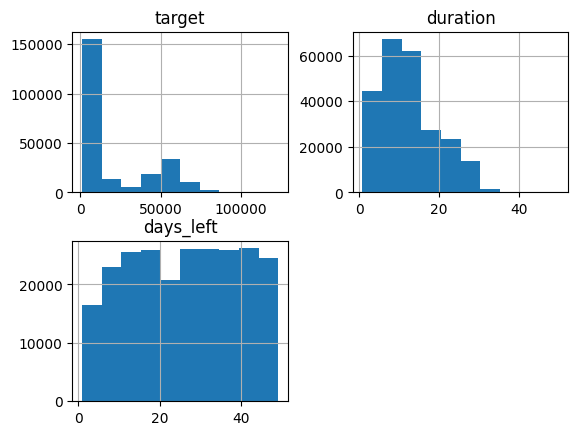

In [96]:
# Análisis univariado variables numéricas
df_train.hist()
plt.show()

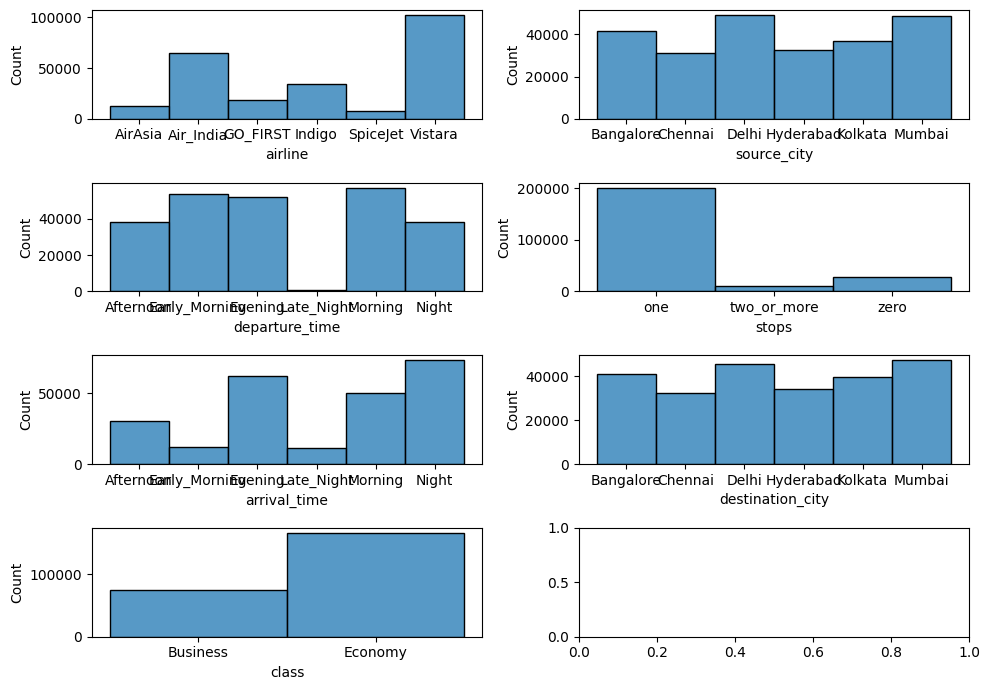

In [97]:
# Análisis univariado variables categóricas
fig, axis = plt.subplots(4, 2, figsize = (10, 7))
sns.histplot(ax = axis[0, 0], data = df_train, x = "airline")
sns.histplot(ax = axis[0, 1], data = df_train, x = "source_city")
sns.histplot(ax = axis[1, 0], data = df_train, x = "departure_time")
sns.histplot(ax = axis[1, 1], data = df_train, x = "stops")
sns.histplot(ax = axis[2, 0], data = df_train, x = "arrival_time")
sns.histplot(ax = axis[2, 1], data = df_train, x = "destination_city")
sns.histplot(ax = axis[3, 0], data = df_train, x = "class")
plt.tight_layout()
plt.show()

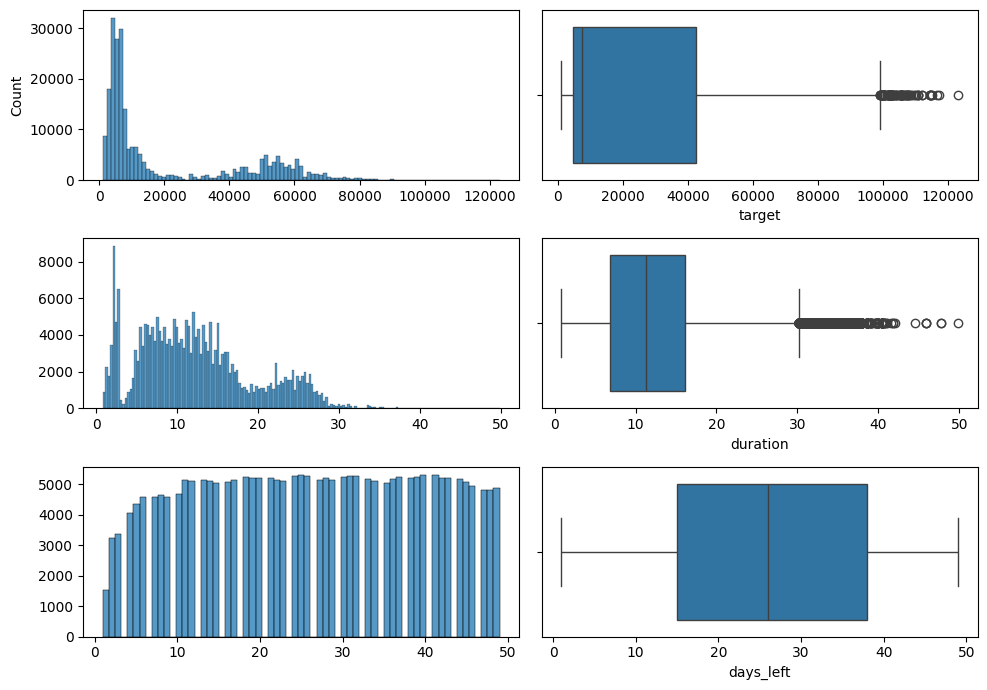

In [99]:
# Análisis variado variables numericas
fig, axis = plt.subplots(3, 2, figsize = (10, 7))
sns.histplot(ax = axis[0, 0], data = df_train, x= "target").set(xlabel = None)
sns.boxplot(ax = axis[0, 1], data = df_train, x = "target")
sns.histplot(ax = axis[1, 0], data = df_train, x = "duration").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[1, 1], data = df_train, x = "duration")
sns.histplot(ax = axis[2, 0], data = df_train, x = "days_left").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[2, 1], data = df_train, x = "days_left")
# Adjust the layout
plt.tight_layout()

# Show the plot
plt.show()

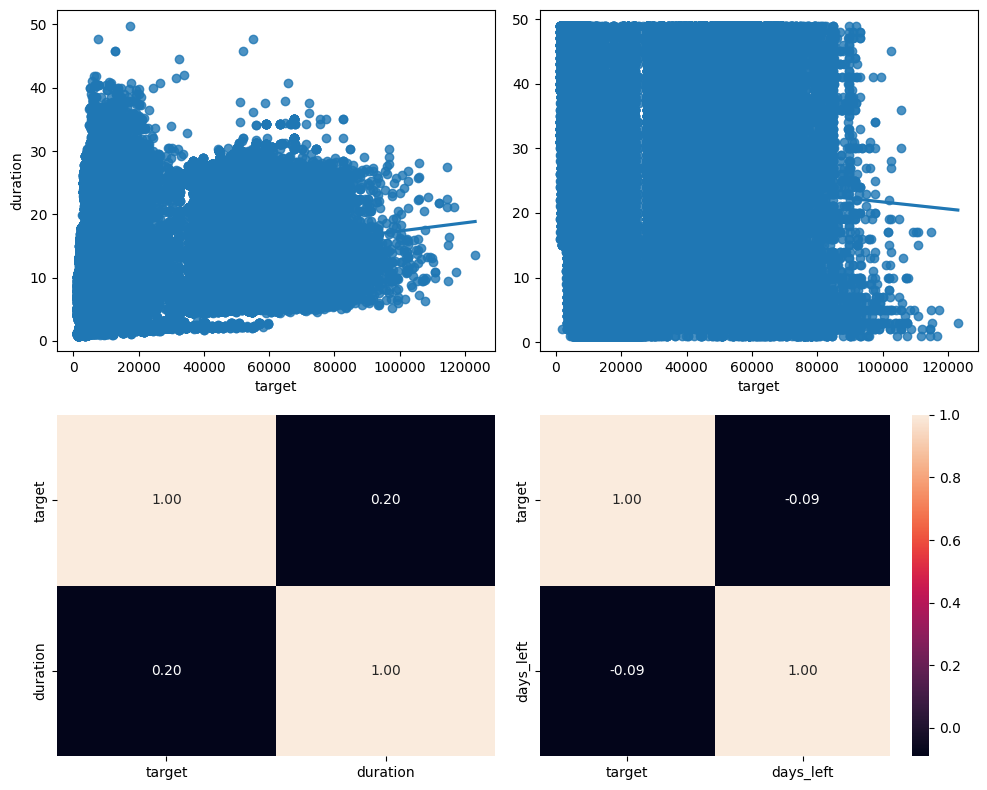

In [100]:
# Análisis bivariado variables categóricas
# Create a multiple scatter diagram
fig, axis = plt.subplots(2, 2, figsize=(10, 8))

# Gráficos de regresión y heatmaps
sns.regplot(ax=axis[0, 0], data=df_train, x="target", y="duration")
sns.heatmap(df_train[["target", "duration"]].corr(), annot=True, fmt=".2f", ax=axis[1, 0], cbar=False)
sns.regplot(ax=axis[0, 1], data=df_train, x="target", y="days_left").set(ylabel=None)
sns.heatmap(df_train[["target", "days_left"]].corr(), annot=True, fmt=".2f", ax=axis[1, 1])

# Ajustar diseño
plt.tight_layout()
plt.show()

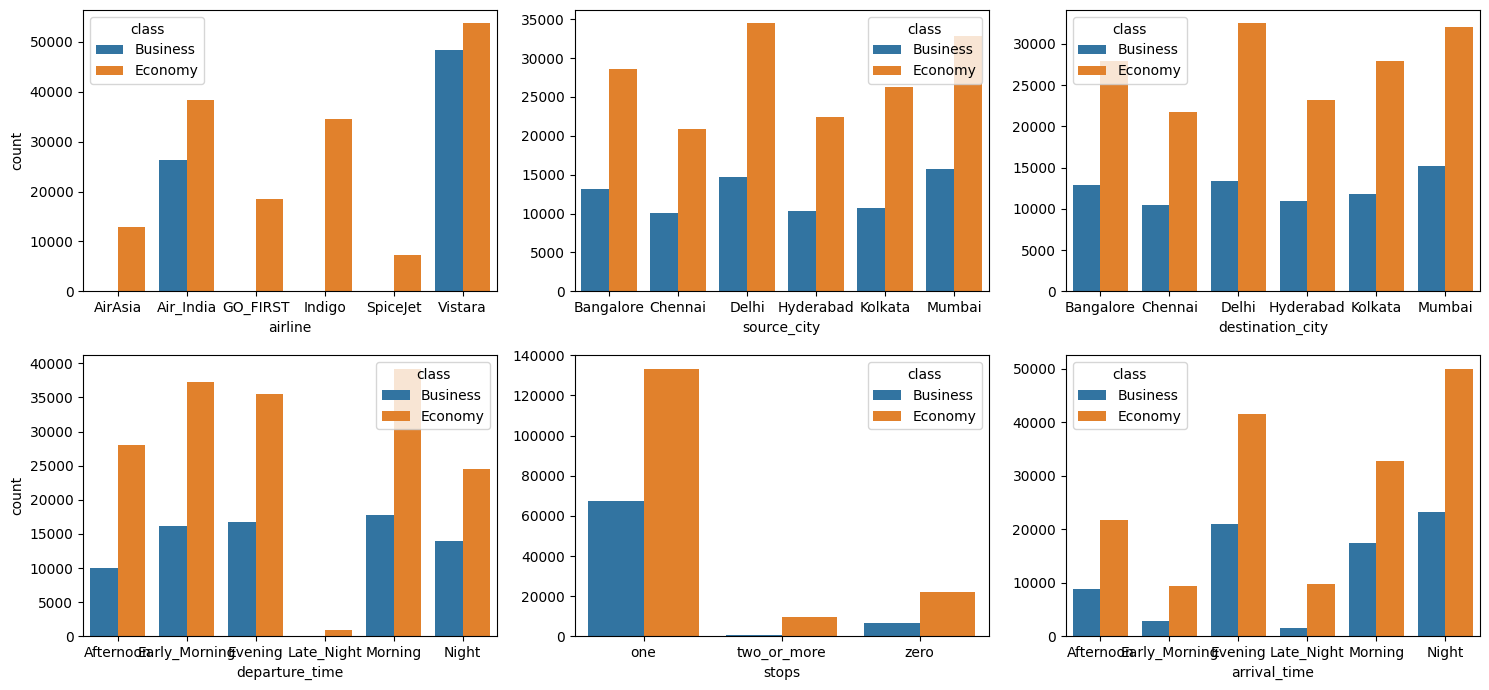

In [101]:
#Análisis bivariado variables categóricas

fig, axis = plt.subplots(2, 3, figsize = (15, 7))

sns.countplot(ax = axis[0, 0], data = df_train, x = "airline", hue = "class")
sns.countplot(ax = axis[0, 1], data = df_train, x = "source_city", hue = "class").set(ylabel = None)
sns.countplot(ax = axis[0, 2], data = df_train, x = "destination_city", hue = "class").set(ylabel = None)
sns.countplot(ax = axis[1, 0], data = df_train, x = "departure_time", hue = "class")
sns.countplot(ax = axis[1, 1], data = df_train, x = "stops", hue = "class").set(ylabel = None)
sns.countplot(ax = axis[1, 2], data = df_train, x = "arrival_time", hue = "class").set(ylabel = None)

plt.tight_layout()
#fig.delaxes(axis[1, 2])

plt.show()

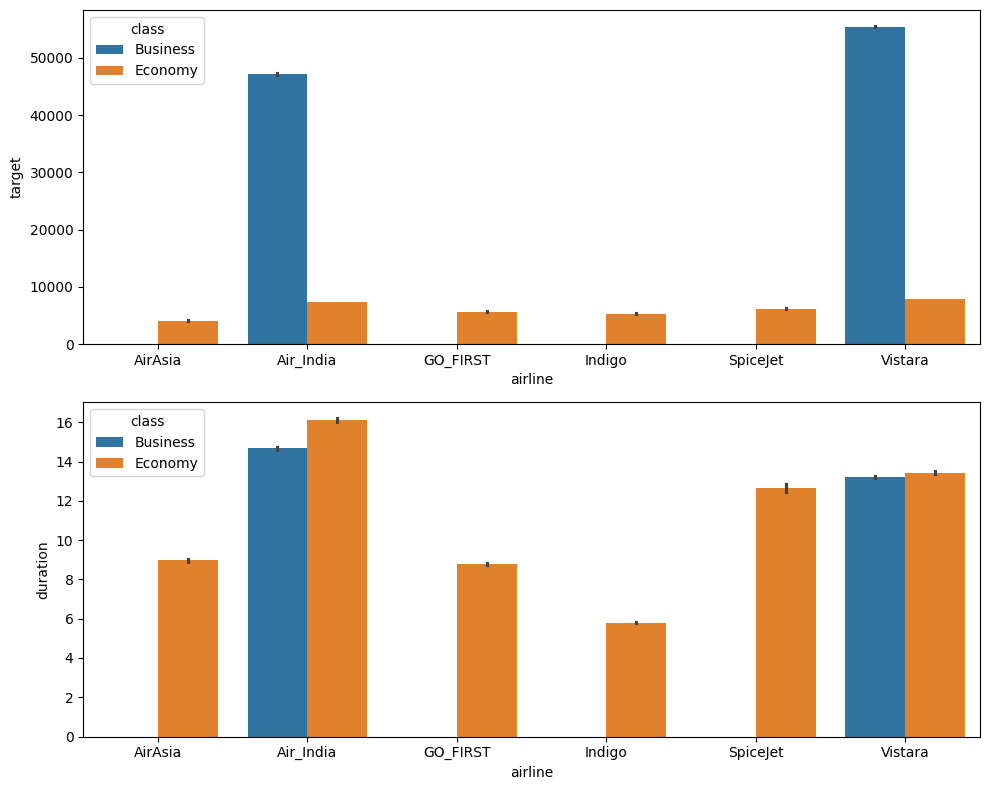

In [102]:
# Crear subgráficos
fig, axis = plt.subplots(2, 1, figsize=(10, 8))

# Primer gráfico
sns.barplot(ax=axis[0], data=df_train, x="airline", y="target", hue="class")

# Segundo gráfico
sns.barplot(ax=axis[1], data=df_train, x="airline", y="duration", hue="class")

# Ajustar diseño
plt.tight_layout()
plt.show()

In [115]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()


In [56]:
#label_encoder = LabelEncoder()
#for col in df_train:
#    df_train[col] = label_encoder.fit_transform(df_train[col])

In [57]:
#df_train.sample(10)

In [58]:
#fig, axis = plt.subplots(figsize = (10, 7))

#sns.heatmap(df_train[["target_log", "duration_log", "days_left", "airline", "source_city", "destination_city", "departure_time", "stops","arrival_time","class"]].corr(), annot = True, fmt = ".2f")
#plt.tight_layout()
#plt.show()

Observamos que las variables que tienen más impacto en el precio (target_log) son la clase, la aerolínea y la duración del vuelo. 

In [103]:
# Step 4. Experiment with models
# 4.1 Split features and reponse
X_train = df_train.drop(['target', 'days_left', 'source_city', 'destination_city', 'stops', 'arrival_time'], axis=1).reset_index(drop=True)
y_train = df_train['target'].reset_index(drop=True)
X_test = df_test.drop(['target', 'days_left', 'source_city', 'destination_city', 'stops', 'arrival_time'], axis=1).reset_index(drop=True)
y_test = df_test['target'].reset_index(drop=True)

In [104]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240122 entries, 0 to 240121
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype   
---  ------          --------------   -----   
 0   airline         240122 non-null  category
 1   departure_time  240122 non-null  category
 2   class           240122 non-null  category
 3   duration        240122 non-null  float64 
dtypes: category(3), float64(1)
memory usage: 2.5 MB


In [105]:
y_train.info()

<class 'pandas.core.series.Series'>
RangeIndex: 240122 entries, 0 to 240121
Series name: target
Non-Null Count   Dtype
--------------   -----
240122 non-null  int64
dtypes: int64(1)
memory usage: 1.8 MB


In [107]:
# 4.2 Modelo simple 
y_mean = np.repeat(df_train["target"].mean(),len(y_test))
print(f'MSE: {mean_squared_error(y_test,y_mean)}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test,y_mean))}')

print(f'MAE: {mean_absolute_error(y_test,y_mean)}')
print(f'R2: {r2_score(y_test,y_mean)}')

MSE: 516647660.3662721
RMSE: 22729.884741596736
MAE: 19780.48752245824
R2: -2.452362734439717e-06


In [108]:
num_cols = X_train.select_dtypes('number').columns
cat_cols = X_train.select_dtypes('category').columns

In [109]:
# Pipelines because we have numeric and non numeric values
cat_proc = Pipeline([
    ('imputer', SimpleImputer(strategy= 'most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first')) # ignore unknow
])
num_proc = Pipeline([
    ('nimputer', SimpleImputer(strategy= 'mean')),
    ('scaler', MinMaxScaler())
])
processor = ColumnTransformer([
    #('cat', cat_proc, cat_cols),
    ('num', num_proc, num_cols)
])

In [110]:
reg_lin = Pipeline([
    ('proc', processor),
    ('lin', LinearRegression())
])

In [111]:
# Modelo de regresión lineal 
reg_lin.fit(X_train,y_train)
y_pred = reg_lin.predict(X_test)
y_pred

array([24564.80772718, 19008.39043143, 20088.62522583, ...,
       14428.71238092, 14105.28878978, 26770.55661874])

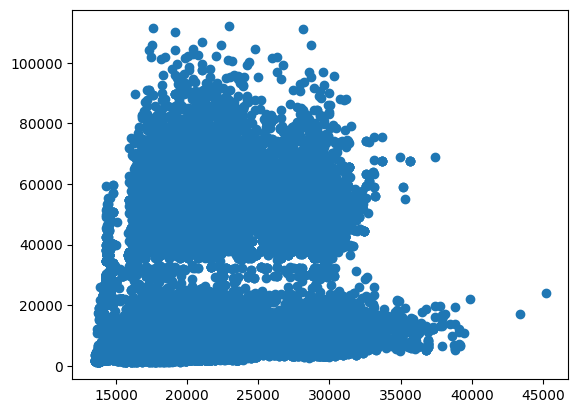

In [113]:
plt.scatter(y_pred,y_test)
#plt.plot([5,10], [5,10], c= 'r')
#plt.xlim([5,12])
#plt.ylim([5,12])

plt.show()

In [114]:
print(f'MSE: {mean_squared_error(y_test,y_pred)}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test,y_pred))}')

print(f'MAE: {mean_absolute_error(y_test,y_pred)}')
print(f'R2: {r2_score(y_test,y_pred)}')

MSE: 495718510.4658568
RMSE: 22264.73692783853
MAE: 19184.68088533744
R2: 0.04050716924562647


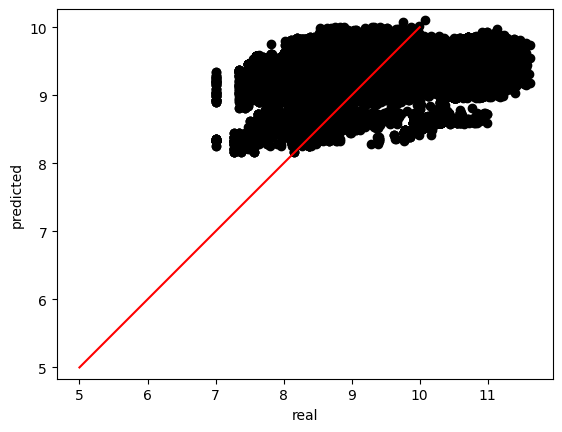

In [77]:
plt.scatter(x= y_test, y= y_pred, c= 'k')
plt.plot([5,10], [5,10], c= 'r')
plt.axis('equal')
plt.xlabel('real')
plt.ylabel('predicted')
plt.show()